## Part 3 text classification
### Muhammad Athallah Yakarazi (24/532752/PA/22532)



#### Import python libraries

In [13]:
# part 3 text classification

# Muhammad Athallah Yakarazi (24/532752/PA/22532)

import pandas as pd
import re # built-in regex library
import math

# sklearn library for train/test split, multinomial naivebayes, logistical regression, and metrics
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import numpy as np # Because scikit-learn classifiers require the feature matrix (X) to be a two-dimensional array-like structure, such as a 2D NumPy array.

# external data visualisation library
import matplotlib.pyplot as plt
import seaborn as sns

#### Load corpus into pandas dataframe and apply corpus preprocessing

In [3]:
file_name = 'spam.csv'
df = pd.read_csv(file_name, encoding='latin-1')
#print(df.head())

# Common english stopwords https://gist.github.com/sebleier/554280
# I chose the stopwords listed there because it saves me work of having to manually gather them myself and they are already comprehensive
STOP_WORDS = {
 'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 'yourself',
 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself',
 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that',
 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as',
 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through',
 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off',
 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should',
 'now'
}

def stemmer(word):
    if word.endswith('ies') and len(word) > 4:
        return word[:-3] + 'y'  # e.g., 'cities' -> 'city'
    elif word.endswith('es') and len(word) > 3:
        return word[:-2]        # e.g., 'foxes' -> 'fox'
    elif word.endswith('s') and len(word) > 2:
        return word[:-1]        # e.g., 'cats' -> 'cat'
    elif word.endswith('ing') and len(word) > 4:
        return word[:-3]        # e.g., 'running' -> 'runn'
    elif word.endswith('ed') and len(word) > 3:
        return word[:-2]        # e.g., 'walked' -> 'walk'
    elif word.endswith('ly') and len(word) > 3:
        return word[:-2]        # e.g., 'badly' -> 'bad'
    return word

def preprocess_corpus(text):
    if not isinstance(text, str):
        return []
    # Lowercase, remove punctuation marks and numbers
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenisation then stopword removal then stemming
    tokens = text.split()
    processed_words = [word for word in tokens if word not in STOP_WORDS]
    stemmed_processed_words = [stemmer(word) for word in processed_words]

    return stemmed_processed_words

df['processed_tokens'] = df['v2'].fillna('').apply(preprocess_corpus)
#print(df['processed_tokens'].iloc[[69]])
#print(df['processed_tokens'].head())

nth_row = 166 # My handpicked document in the dataset for specific document scorings

#### Bag of Words representation

In [4]:
# Bag of Words

# Vocabulary list
vocabulary = {}
for tokens in df['processed_tokens']:
    for token in tokens:
        if token not in vocabulary:
            vocabulary[token] = len(vocabulary)
#print(vocabulary)

# Create bag of words vector adapted from https://www.datacamp.com/tutorial/python-bag-of-words-model
def create_bow_vector(tokens , vocab):
    vector = [0] * len(vocab)  # Init a vector of zeros
    for word in tokens:
        if word in vocab:
            idx = vocab.index(word)  # Find the index of the word in the vocabulary
            vector[idx] += 1  # Increment the count at that index

    return vector

# Apply the function to create a new column with the vectors
def apply_create_bow_vector(tokens):
    return create_bow_vector(tokens, list(vocabulary.keys()))

df['bow_vector'] = df['processed_tokens'].apply(apply_create_bow_vector)
#print(df['bow_vector'].head())

# Dimensionality
print(f"Vocabulary size: {len(vocabulary)}")
print(f"Vector Length: {len(df['bow_vector'])}")
print(f"Dimensionality: {len(df['bow_vector'][0])}")

# Reverse the vocabulary mapping (index -> word) so it can be numerically ranked for the highest weighted terms under TF-IDF later
index_to_word = {index: word for word, index in vocabulary.items()}

# 10 Highest weighted terms under BoW
# Retrieve BoW vector for the specific document then pair words with their counts if count more than 0
doc_bow_vector = df['bow_vector'].iloc[nth_row]
bow_term_scores = [
    (index_to_word[idx], count) for idx, count in enumerate(doc_bow_vector) if count > 0
]

# Sort descending by count and select the top 10
top_10_bow = sorted(bow_term_scores, key=lambda x: x[1], reverse=True)[:10]

print(f"\nTop 10 BoW scores for document {nth_row}:")
print(f"{'Term'}, {'BoW Count'}")
for word, count in top_10_bow:
    print(f"{word:}, {count}")

Vocabulary size: 7409
Vector Length: 5572
Dimensionality: 7409

Top 10 BoW scores for document 166:
Term, BoW Count
prize, 1
claim, 1
call, 1
code, 1
valid, 1
urgent, 1
won, 1
try, 1
weekend, 1
guarante, 1


#### TF-IDF representation

In [14]:
# TF-IDF

N = len(df) # Total number of document

# Init document frequencies
document_frequencies = {}
for word in vocabulary:
    document_frequencies[word] = 0 # start with 0 documents are containing that word

# Count of how many documents contain each word
for tokens in df['processed_tokens']:
    unique_words_in_doc = set(tokens) # because set do not allow duplicate values
    # print(unique_words_in_doc)
    for word in unique_words_in_doc:
        if word in document_frequencies:
            document_frequencies[word] += 1
#print(document_frequencies)

# IDF for each word
idf_dictionary = {}
for word, doc_count in document_frequencies.items():
    idf_dictionary[word] = math.log((N + 1) / (doc_count + 1)) # Smoothed IDF

def create_tfidf_vector(tokens, vocab, idf_dict):
    # Init a vector of zeros matching the vocabulary size
    vector = [0.0] * len(vocab)
    total_tokens = len(tokens)

    # Return early if the document is empty to prevent divide by zero error
    if total_tokens == 0:
        return vector

    # Calculate TF for the current document
    term_counts = {}
    for word in tokens:
        term_counts[word] = term_counts.get(word, 0) + 1

    # Calculate the final TF-IDF score for each word in the document
    for word, count in term_counts.items():
        if word in vocab:
            # Normalised TF: word count divided by total words in the document then place the score at the correct index in the vector
            tf = count / total_tokens
            tfidf_score = tf * idf_dict[word]
            vector[vocab[word]] = tfidf_score

    return vector

# Apply the function to create a new column with the vectors
def apply_create_tfidf_vector(tokens):
    return create_tfidf_vector(tokens, vocabulary, idf_dictionary)

df['tfidf_vector'] = df['processed_tokens'].apply(apply_create_tfidf_vector)
#print(df['tfidf_vector'].head())

# Dimensionality
print(f"Vector Length: {len(df['tfidf_vector'])}")
print(f"Dimensionality: {len(df['tfidf_vector'][0])}")

# 10 Highest under TF-IDF
doc_tfidf_vector = df['tfidf_vector'].iloc[nth_row] # Retrieve

# Pair words with their TF-IDF scores filter out 0.0 scores
tfidf_term_scores = [
    (index_to_word[idx], score) for idx, score in enumerate(doc_tfidf_vector) if score > 0.0
]

# Sort descending by the TF-IDF score and select the top 10
top_10_tfidf = sorted(tfidf_term_scores, key=lambda x: x[1], reverse=True)[:10]

print(f"\nTop 10 TF-IDF scores for document {nth_row}:")
print(f"{'Term'}, {'TF-IDF Score'}")
for word, score in top_10_tfidf:
    print(f"{word:}, {score:.4f}")

Vector Length: 5572
Dimensionality: 7409

Top 10 TF-IDF scores for document 166:
Term, TF-IDF Score
valid, 0.3632
code, 0.3461
weekend, 0.3291
hr, 0.3291
draw, 0.3228
guarante, 0.3129
urgent, 0.2968
show, 0.2918
won, 0.2881
contact, 0.2863


#### Prepare data for training, init the sklearn classifiers, and covert the pandas dataframe to 2D NumPy arrays so it can be passed to scikit

In [24]:
# Target variable preparation, ham = 0, spam = 1
y = df['v1'].map({'ham': 0, 'spam': 1})

# Init the classifiers, they are Multinonial Naive Bayes and Logistical Regression
nb_classifier_tfidf = MultinomialNB()
lr_classifier_tfidf = LogisticRegression()
nb_classifier_bow = MultinomialNB()
lr_classifier_bow = LogisticRegression()

# Convert the pandas Series of lists into proper 2D NumPy arrays so it can be passed to scikit
X_tfidf = np.array(df['tfidf_vector'].to_list())
X_bow = np.array(df['bow_vector'].to_list())
#print(X_tfidf)
#print(X_bow)

#### Train on TF-IDF

Naive Bayes Accuracy (TF-IDF): 0.9443946188340807
              precision    recall  f1-score   support

     Ham (0)       0.98      0.95      0.97       965
    Spam (1)       0.75      0.88      0.81       150

    accuracy                           0.94      1115
   macro avg       0.87      0.92      0.89      1115
weighted avg       0.95      0.94      0.95      1115

Logistic Regression Accuracy (TF-IDF): 0.9668161434977578
              precision    recall  f1-score   support

     Ham (0)       0.97      0.99      0.98       965
    Spam (1)       0.93      0.81      0.87       150

    accuracy                           0.97      1115
   macro avg       0.95      0.90      0.92      1115
weighted avg       0.97      0.97      0.97      1115



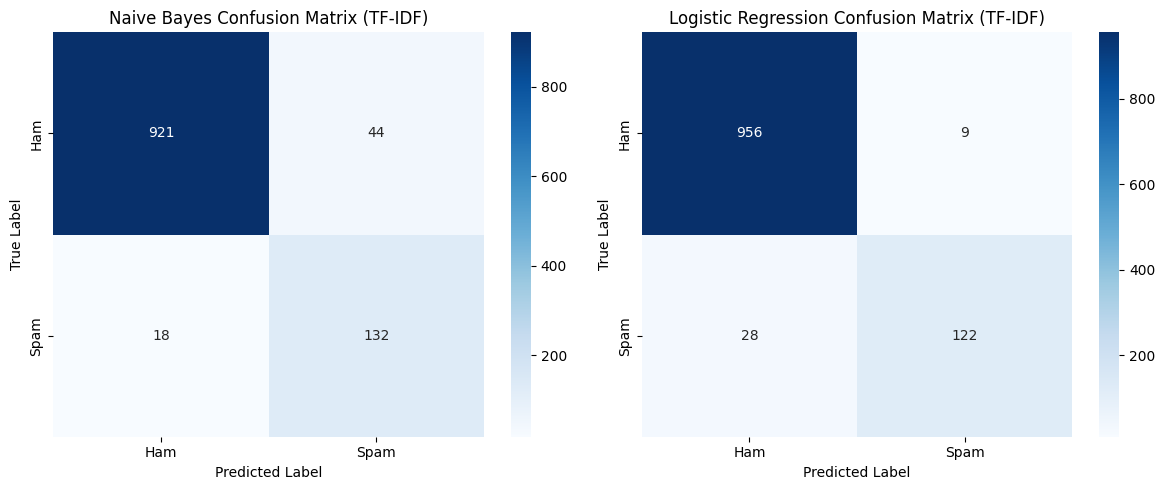

In [25]:
# Train on TF-IDF

# 80/20 train/test split
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# Train on training data and generate predictions on test data
nb_classifier_tfidf.fit(X_train_tfidf, y_train_tfidf)
lr_classifier_tfidf.fit(X_train_tfidf, y_train_tfidf)
nb_predictions_tfidf = nb_classifier_tfidf.predict(X_test_tfidf)
lr_predictions_tfidf = lr_classifier_tfidf.predict(X_test_tfidf)

# Evaluate on test data
nb_accuracy_tfidf = accuracy_score(y_test_tfidf, nb_predictions_tfidf)
lr_accuracy_tfidf = accuracy_score(y_test_tfidf, lr_predictions_tfidf)

print(f"Naive Bayes Accuracy (TF-IDF): {nb_accuracy_tfidf}")
print(classification_report(y_test_tfidf, nb_predictions_tfidf, target_names=['Ham (0)', 'Spam (1)']))
print(f"Logistic Regression Accuracy (TF-IDF): {lr_accuracy_tfidf}")
print(classification_report(y_test_tfidf, lr_predictions_tfidf, target_names=['Ham (0)', 'Spam (1)']))

# Generate confusion matrices (CM) with sklearn confusion_matrix()
nb_cm_tfidf = confusion_matrix(y_test_tfidf, nb_predictions_tfidf)
lr_cm_tfidf = confusion_matrix(y_test_tfidf, lr_predictions_tfidf)
#print(nb_cm_tfidf)
#print(lr_cm_tfidf)

# Set up the matplotlib figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Naive Bayes CM
sns.heatmap(nb_cm_tfidf, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Naive Bayes Confusion Matrix (TF-IDF)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Logistic Regression CM
sns.heatmap(lr_cm_tfidf, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1].set_title('Logistic Regression Confusion Matrix (TF-IDF)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Adjust layout and render the plot
plt.tight_layout()
plt.show()

#### Train on Bag of Words

Naive Bayes Accuracy (Bag of Words): 0.9659192825112107
              precision    recall  f1-score   support

     Ham (0)       0.98      0.98      0.98       965
    Spam (1)       0.86      0.89      0.88       150

    accuracy                           0.97      1115
   macro avg       0.92      0.94      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Logistic Regression Accuracy (Bag of Words): 0.9811659192825112
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       965
    Spam (1)       1.00      0.86      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



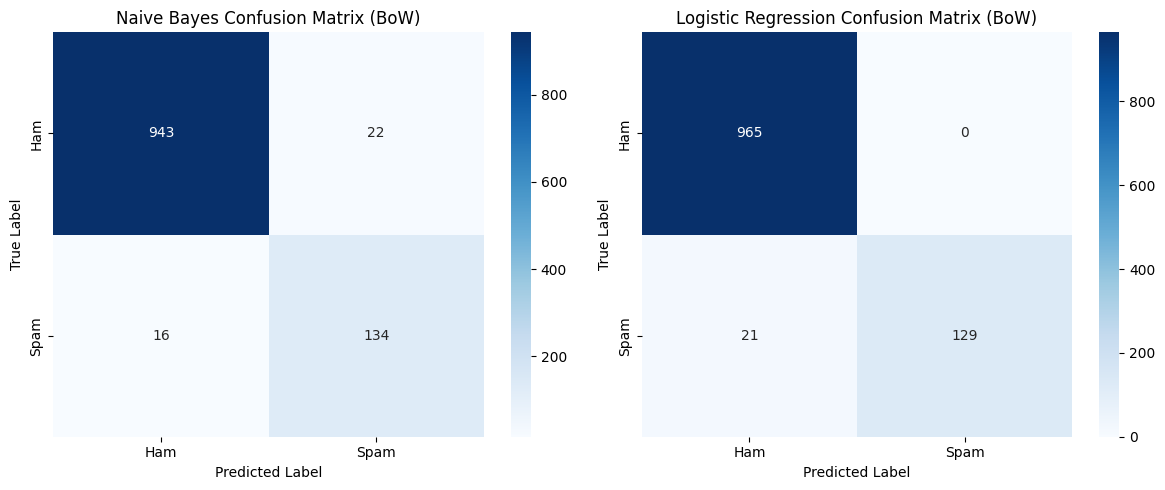

In [23]:
# Train on BoW

# 80/20 train/test split
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

# Train on training data and generate predictions on test data
nb_classifier_bow.fit(X_train_bow, y_train_bow)
lr_classifier_bow.fit(X_train_bow, y_train_bow)
nb_predictions_bow = nb_classifier_bow.predict(X_test_bow)
lr_predictions_bow = lr_classifier_bow.predict(X_test_bow)

# Evaluate on test data
nb_accuracy_bow = accuracy_score(y_test_bow, nb_predictions_bow)
lr_accuracy_bow = accuracy_score(y_test_bow, lr_predictions_bow)

print(f"Naive Bayes Accuracy (Bag of Words): {nb_accuracy_bow}")
print(classification_report(y_test_bow, nb_predictions_bow, target_names=['Ham (0)', 'Spam (1)']))
print(f"Logistic Regression Accuracy (Bag of Words): {lr_accuracy_bow}")
print(classification_report(y_test_bow, lr_predictions_bow, target_names=['Ham (0)', 'Spam (1)']))

# Generate confusion matrices (CM) with sklearn confusion_matrix()
nb_cm_bow = confusion_matrix(y_test_bow, nb_predictions_bow)
lr_cm_bow = confusion_matrix(y_test_bow, lr_predictions_bow)
#print(nb_cm_bow)
#print(lr_cm_bow)

# Set up the matplotlib figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Naive Bayes CM
sns.heatmap(nb_cm_bow, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Naive Bayes Confusion Matrix (BoW)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Logistic Regression CM
sns.heatmap(lr_cm_bow, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1].set_title('Logistic Regression Confusion Matrix (BoW)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

# Adjust layout and render the plot
plt.tight_layout()
plt.show()

#### Pick 3 Misclassified from TF-IDF

In [21]:
# Map the original text, true labels, and predictions together using the test indexes
nb_tfidf_error_analysis_df = pd.DataFrame({
    'Raw Text': df.loc[y_test_tfidf.index, 'v2'],
    'True Label': y_test_tfidf,
    'Predicted Label': nb_predictions_tfidf
})
lr_tfidf_error_analysis_df = pd.DataFrame({
    'Raw Text': df.loc[y_test_tfidf.index, 'v2'],
    'True Label': y_test_tfidf,
    'Predicted Label': lr_predictions_tfidf
})

# Filter for rows where the prediction does not match the true label and select 3 samples
nb_misclassified_df = nb_tfidf_error_analysis_df[nb_tfidf_error_analysis_df['True Label'] != nb_tfidf_error_analysis_df['Predicted Label']]
lr_misclassified_df = lr_tfidf_error_analysis_df[lr_tfidf_error_analysis_df['True Label'] != lr_tfidf_error_analysis_df['Predicted Label']]
nb_sample_misclassifications = nb_misclassified_df.head(3)
lr_sample_misclassifications = lr_misclassified_df.head(3)

print("Misclassified TF-IDF Samples (Naive Bayes):")
for original_idx, row in nb_sample_misclassifications.iterrows():
    # Convert binary labels back to readable text
    true_class = 'Spam (1)' if row['True Label'] == 1 else 'Ham (0)'
    pred_class = 'Spam (1)' if row['Predicted Label'] == 1 else 'Ham (0)'

    print(f"Original Index: {original_idx}")
    print(f"True Class: {true_class} | Predicted Class: {pred_class}")
    print(f"Message: {row['Raw Text']}\n")
print("-"*21)
print("Misclassified TF-IDF Samples (Logistic Regression):")
for original_idx, row in lr_sample_misclassifications.iterrows():
  true_class = 'Spam (1)' if row['True Label'] == 1 else 'Ham (0)'
  pred_class = 'Spam (1)' if row['Predicted Label'] == 1 else 'Ham (0)'

  print(f"Original Index: {original_idx}")
  print(f"True Class: {true_class} | Predicted Class: {pred_class}")
  print(f"Message: {row['Raw Text']}\n")

Misclassified TF-IDF Samples (Naive Bayes):
Original Index: 1344
True Class: Ham (0) | Predicted Class: Spam (1)
Message: Were somewhere on Fredericksburg

Original Index: 3142
True Class: Ham (0) | Predicted Class: Spam (1)
Message: Boy; I love u Grl: Hogolo Boy: gold chain kodstini Grl: Agalla Boy: necklace madstini Grl: agalla Boy: Hogli 1 mutai eerulli kodthini! Grl: I love U kano;-)

Original Index: 683
True Class: Spam (1) | Predicted Class: Ham (0)
Message: Hi I'm sue. I am 20 years old and work as a lapdancer. I love sex. Text me live - I'm i my bedroom now. text SUE to 89555. By TextOperator G2 1DA 150ppmsg 18+

---------------------
Misclassified TF-IDF Samples (Logistic Regression):
Original Index: 683
True Class: Spam (1) | Predicted Class: Ham (0)
Message: Hi I'm sue. I am 20 years old and work as a lapdancer. I love sex. Text me live - I'm i my bedroom now. text SUE to 89555. By TextOperator G2 1DA 150ppmsg 18+

Original Index: 4700
True Class: Ham (0) | Predicted Class: 